# Import Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Load the Dataset

In [45]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chirag19/air-passengers")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'air-passengers' dataset.
Path to dataset files: /kaggle/input/air-passengers


In [46]:
df = pd.read_csv(path + "/AirPassengers.csv")

# Check First 5 Rows

In [47]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


# Check the Datatype

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


# 5 Point summary Data

In [49]:
df.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


# Check Duplicate Values

In [50]:
df.duplicated().sum()

np.int64(0)

# Check Null Values

In [51]:
df.isnull().sum()

,0
Month,0
#Passengers,0


# Time Series Plot

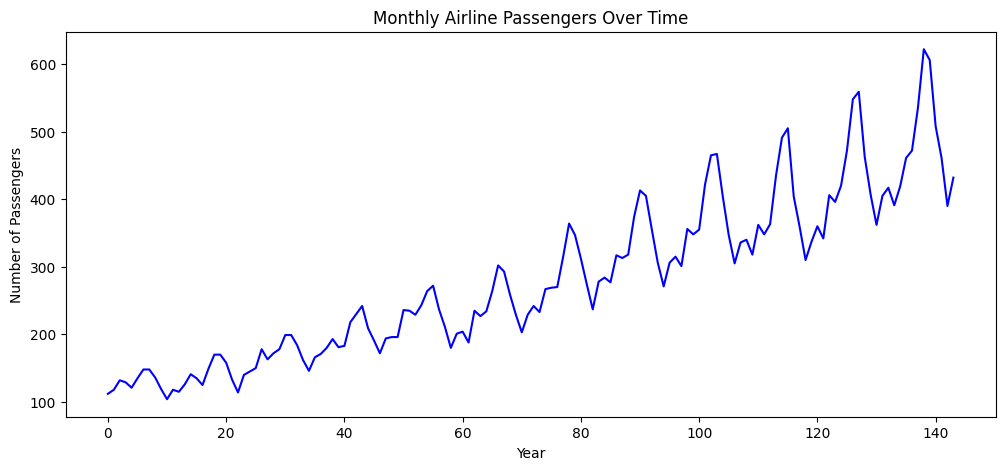

In [52]:
plt.figure(figsize=(12,5))
plt.plot(df['#Passengers'], color='blue')
plt.title("Monthly Airline Passengers Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.show()

# Rolling Statistics (Trend Analysis)

In [53]:
rolling_mean = df['#Passengers'].rolling(window=12).mean()
rolling_std = df['#Passengers'].rolling(window=12).std()

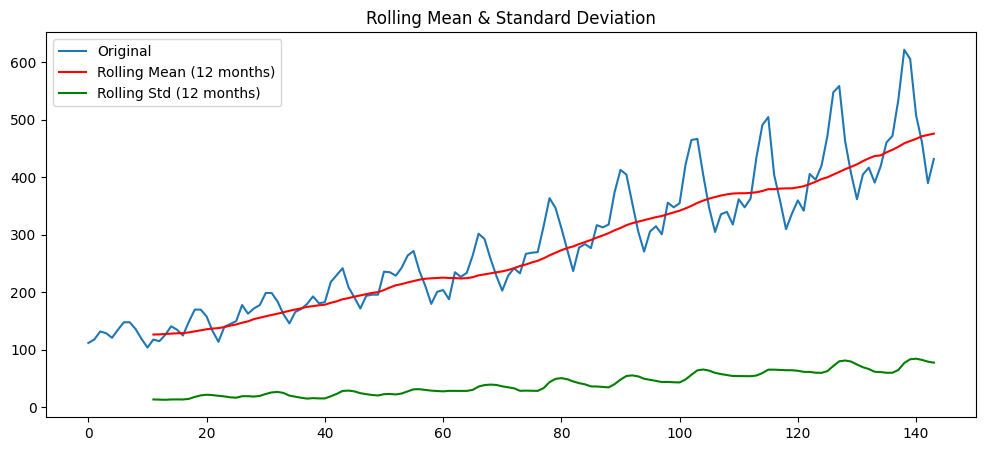

In [54]:
plt.figure(figsize=(12,5))
plt.plot(df['#Passengers'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean (12 months)', color='red')
plt.plot(rolling_std, label='Rolling Std (12 months)', color='green')
plt.legend()
plt.title("Rolling Mean & Standard Deviation")
plt.show()

# Distribution Analysis

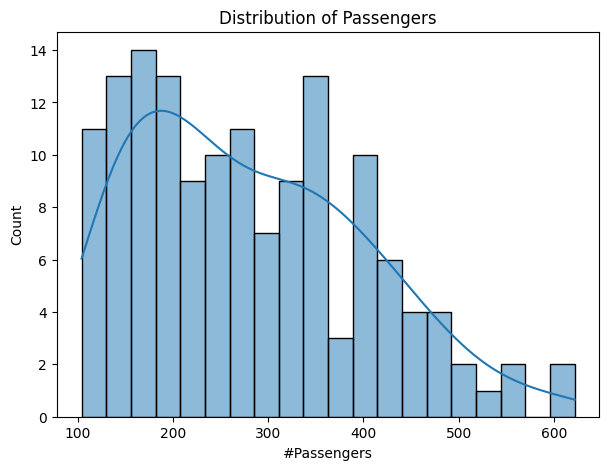

In [55]:
plt.figure(figsize=(7,5))
sns.histplot(df['#Passengers'], bins=20, kde=True)
plt.title("Distribution of Passengers")
plt.show()

# Boxplot (Outlier Detection

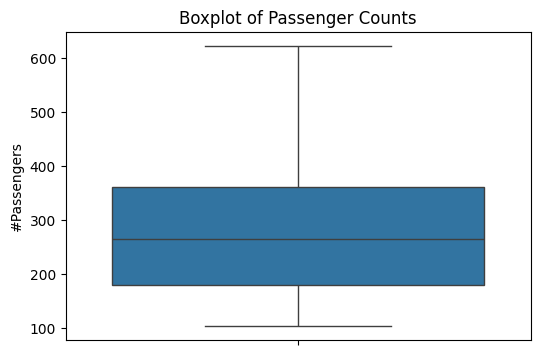

In [56]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['#Passengers'])
plt.title("Boxplot of Passenger Counts")
plt.show()

# Monthly wise Analysis

In [57]:
df['Month'] = pd.to_datetime(df['Month'])
df['Month_num'] = df['Month'].dt.month
monthly_avg = df.groupby('Month_num')['#Passengers'].mean()

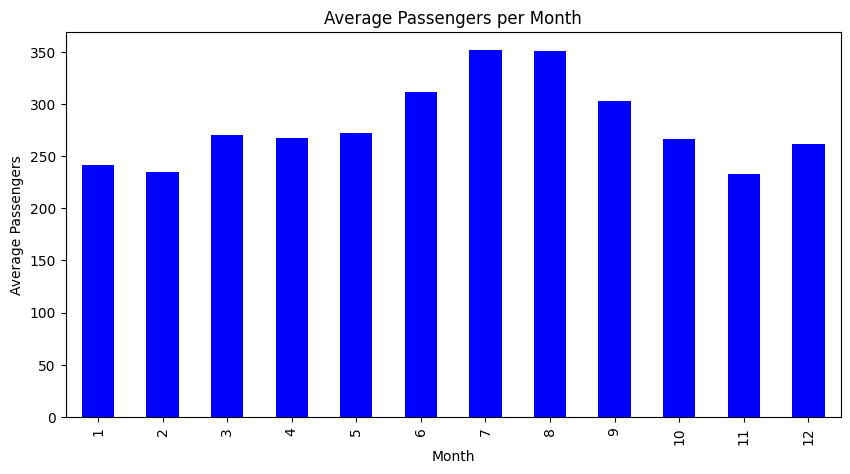

In [58]:
plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar', color='blue')
plt.title("Average Passengers per Month")
plt.xlabel("Month")
plt.ylabel("Average Passengers")
plt.show()


# Year wise Analysis

In [59]:
df['Year'] = df['Month'].dt.year
yearly_avg = df.groupby('Year')['#Passengers'].mean()

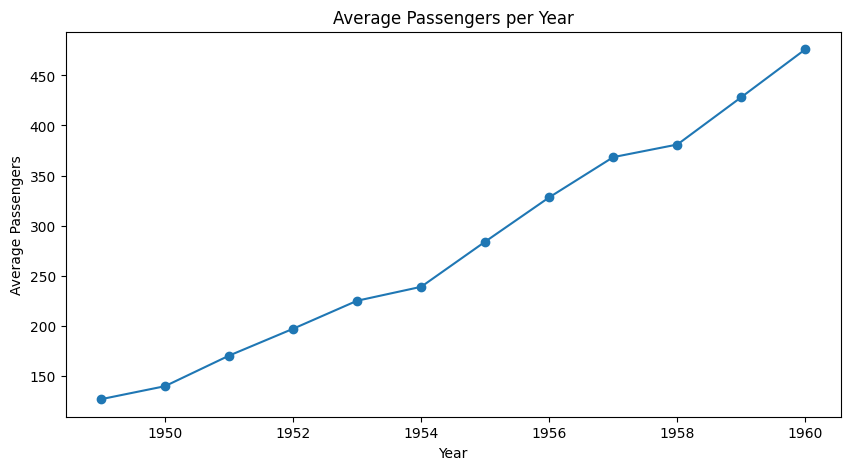

In [60]:
plt.figure(figsize=(10,5))
yearly_avg.plot(marker='o')
plt.title("Average Passengers per Year")
plt.xlabel("Year")
plt.ylabel("Average Passengers")
plt.show()

# Heatmap (Year vs Month)

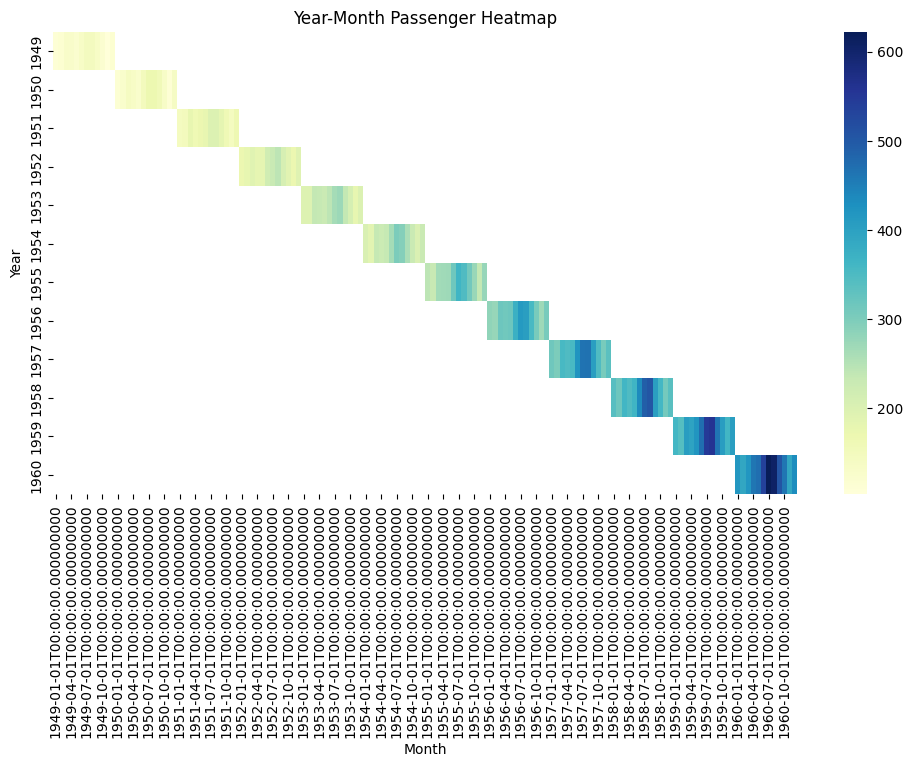

In [61]:
pivot = df.pivot_table(values='#Passengers',
                       index='Year',
                       columns='Month')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title("Year-Month Passenger Heatmap")
plt.show()

# Train test split

In [62]:
df.set_index('Month', inplace=True)
train = df['#Passengers'][:'1958']
test = df['#Passengers']['1959':]

# Arima Forecasting

In [63]:
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


# Model Evaluation

In [64]:
mse = mean_squared_error(test, forecast)
print('Mean Squared Error: ', mse)

Mean Squared Error:  8225.458620459793


# Forecast Plot

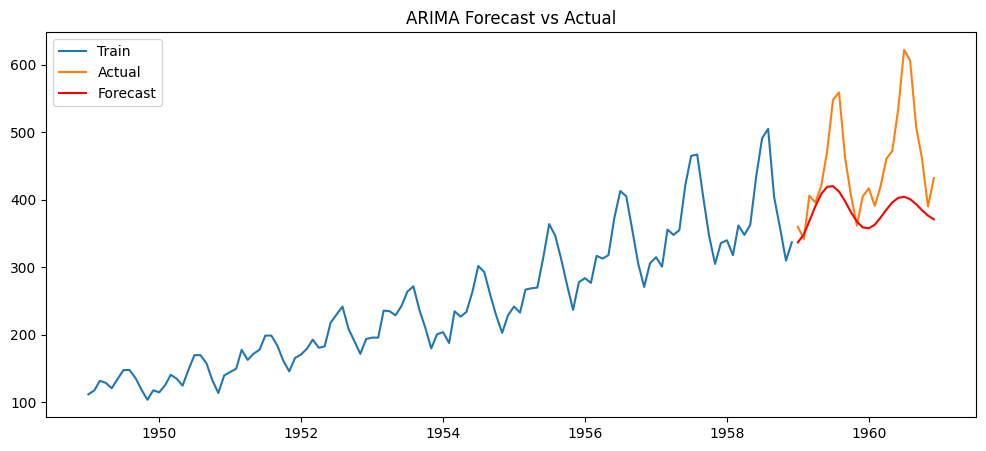

In [65]:
plt.figure(figsize=(12,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()